# 🗺️ Product Roadmap Visualizer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/roadmap-viz/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/roadmap-viz/demo.ipynb)

> **Roadmaps are PowerPoints that go stale the day after the offsite.** Generate the roadmap from data instead — a Gantt-style timeline, grouped by lane, colored by status, with a "today" line.

**Covers:** roadmap items as data → a timeline chart → status colors + today marker → try your own.


## Step 1 — A roadmap is just rows

Each initiative is `name, lane, start, end, status`. Once it's data, the chart is deterministic and the roadmap never drifts from reality — you update a row, not a slide.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import date, datetime

STATUS_COLORS = {"done": "#2e9e5b", "in-progress": "#4361ee", "planned": "#b0b0b0", "at-risk": "#d64545"}


@dataclass
class RoadmapItem:
    name: str
    lane: str
    start: str
    end: str
    status: str = "planned"

    @property
    def start_date(self): return datetime.strptime(self.start, "%Y-%m-%d").date()
    @property
    def end_date(self): return datetime.strptime(self.end, "%Y-%m-%d").date()
    @property
    def duration_days(self): return (self.end_date - self.start_date).days


items = [
    RoadmapItem("Auth revamp", "Platform", "2026-01-01", "2026-02-15", "done"),
    RoadmapItem("Mobile app", "Platform", "2026-02-15", "2026-05-30", "in-progress"),
    RoadmapItem("SSO / SAML", "Platform", "2026-06-01", "2026-07-15", "planned"),
    RoadmapItem("Onboarding flow", "Growth", "2026-01-15", "2026-03-01", "done"),
    RoadmapItem("Referral program", "Growth", "2026-03-15", "2026-05-01", "at-risk"),
    RoadmapItem("Data warehouse", "Data", "2026-02-01", "2026-04-15", "in-progress"),
    RoadmapItem("Self-serve analytics", "Data", "2026-04-15", "2026-08-01", "planned"),
]
print(f"{len(items)} items across {len(set(i.lane for i in items))} lanes")


7 items across 3 lanes


## Step 2 — Render the timeline

A horizontal bar per item, positioned on a real date axis, grouped by lane, colored by status, with a dashed **today** line so anyone can see what's late, active, or upcoming at a glance.


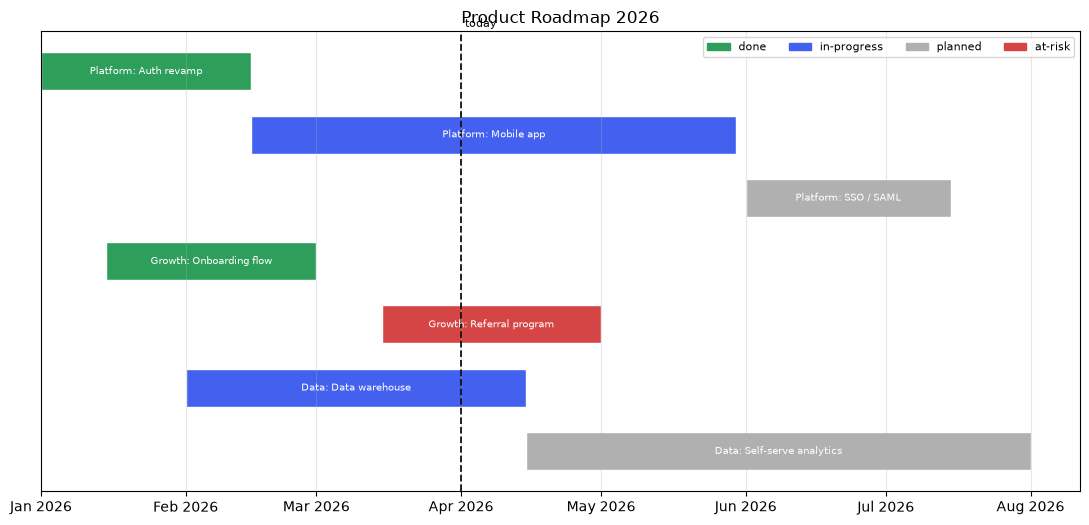

In [2]:
%matplotlib inline
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

today = date(2026, 4, 1)
lanes = {}
for it in items:
    lanes.setdefault(it.lane, []).append(it)
rows = [it for lane in lanes for it in sorted(lanes[lane], key=lambda x: x.start_date)]

fig, ax = plt.subplots(figsize=(11, 0.55 * len(rows) + 1.5))
for i, it in enumerate(rows):
    y = len(rows) - i - 1
    start_num = mdates.date2num(it.start_date)
    ax.barh(y, max(it.duration_days, 1), left=start_num, height=0.6,
            color=STATUS_COLORS[it.status], edgecolor="white")
    ax.text(start_num + max(it.duration_days, 1) / 2, y, f"{it.lane}: {it.name}",
            ha="center", va="center", fontsize=7, color="white")

ax.set_yticks([]); ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.axvline(mdates.date2num(today), color="#111", linestyle="--", linewidth=1.3)
ax.text(mdates.date2num(today), len(rows) - 0.3, " today", fontsize=8)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in STATUS_COLORS.values()]
ax.legend(handles, STATUS_COLORS.keys(), loc="upper right", fontsize=8, ncol=4)
ax.set_title("Product Roadmap 2026")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("roadmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 3 — Read it

Bars left of the today line should be `done`; bars straddling it are `in-progress`. A `planned` bar behind the line, or an `at-risk` one, is your standup topic. The referral program (red) is the thing to talk about.


In [3]:
for it in items:
    behind = it.end_date < today and it.status != "done"
    flag = "  <-- LATE" if behind else ("  <-- AT RISK" if it.status == "at-risk" else "")
    print(f"{it.lane:9} {it.name:22} {it.status:12}{flag}")


Platform  Auth revamp            done        
Platform  Mobile app             in-progress 
Platform  SSO / SAML             planned     
Growth    Onboarding flow        done        
Growth    Referral program       at-risk       <-- AT RISK
Data      Data warehouse         in-progress 
Data      Self-serve analytics   planned     


## Summary

- **Data, not slides.** A roadmap generated from rows never goes stale — update a field, re-render.
- **Status + time in one view.** Color encodes state, position encodes schedule, the today line ties them together.
- **The chart surfaces the conversation.** At-risk and behind items pop out instead of hiding in a bullet list.

The full app makes the item table editable (with a status dropdown) and re-renders the timeline on demand.


## Try your own roadmap

Replace the items with your initiatives and set `today`. Keep dates as `YYYY-MM-DD`; lanes group the bars.


In [4]:
# my_items = [
#     RoadmapItem("Feature X", "Core", "2026-03-01", "2026-05-01", "in-progress"),
#     RoadmapItem("Feature Y", "Core", "2026-05-01", "2026-06-15", "planned"),
# ]
# print([i.name for i in my_items])


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 56, Mini SaaS Products.

Streamlit version (editable item table + status dropdown + live timeline):
```bash
pip install -r requirements.txt
streamlit run app.py
```
